kind,half_life_d,period_h,share
real,1.18,inf,0.769
osc,2.00,24.0,0.103
real,118.85,inf,0.128


RMSE=0.033589  WSSR=0.5708  (CARMA order 4)


lag_h,empirical,model,err
1,0.9328,0.9765,+0.0437
6,0.7240,0.7921,+0.0681
12,0.6620,0.6149,-0.0471
18,0.5985,0.6232,+0.0247
24,0.6241,0.6284,+0.0044
30,0.4860,0.4971,+0.0110
48,0.4264,0.4166,-0.0099
72,0.3243,0.2950,-0.0292
96,0.2375,0.2247,-0.0128
120,0.1774,0.1837,+0.0063


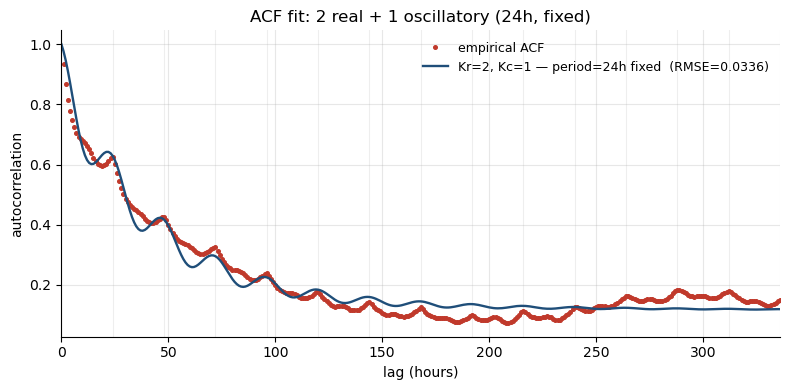

In [50]:
# ── Kr=2, Kc=1 avec période 24h fixée ─────────────────────────────
Kr, Kc = 2, 1
m = Kr + Kc          # 3 composantes au total
OM24 = 2*np.pi/24.0  # fréquence fixe

def rho_24(theta, k):
    """theta = [log_hl_0, log_hl_1, log_hl_2,  s_0, s_1, s_2]"""
    kap = np.log(2) / np.exp(theta[:m])
    sh  = softmax(theta[m:2*m])
    h   = np.asarray(k, float)
    out = sh[0]*np.exp(-kap[0]*h) + sh[1]*np.exp(-kap[1]*h)
    out += sh[2]*np.exp(-kap[2]*h)*np.cos(OM24*h)
    return out

# bornes : osc → t½ ≥ 2 jours (log(48h)), réels libres
lb_hl = [np.log(0.3), np.log(0.3), np.log(48.0)]
ub_hl = [np.log(8760)] * 3
lb = lb_hl + [-9]*3
ub = ub_hl + [ 9]*3

x0  = np.r_[np.log([36., 2000., 96.]), [0.]*3]
rng = np.random.default_rng(42)
best = None
for s in range(16):
    xs = x0.copy()
    if s > 0:
        xs[:m]   += rng.normal(0, 0.4, m)
        xs[m:2*m] += rng.normal(0, 1.0, m)
    xs = np.clip(xs, lb, ub)
    r  = least_squares(lambda t: sw*(rho_24(t, lags)-rho_emp),
                       xs, bounds=(lb, ub), max_nfev=5000)
    if best is None or r.cost < best.cost:
        best = r

kap_b = np.log(2) / np.exp(best.x[:m])
sh_b  = softmax(best.x[m:2*m])

# ── tableau des composantes ────────────────────────────────────────
rows = []
for i in range(Kr):
    rows.append(dict(kind='real', half_life_d=np.log(2)/kap_b[i]/24,
                     period_h=np.inf, share=sh_b[i]))
rows.append(dict(kind='osc',  half_life_d=np.log(2)/kap_b[Kr]/24,
                 period_h=24.0, share=sh_b[Kr]))
summary_24 = pd.DataFrame(rows).sort_values('half_life_d').reset_index(drop=True)
display(summary_24.style.format({'half_life_d':'{:.2f}','period_h':'{:.1f}','share':'{:.3f}'}).hide(axis='index'))

rmse_24 = float(np.sqrt(np.mean((rho_24(best.x, lags)-rho_emp)**2)))
wssr_24 = float(np.sum((sw*(rho_24(best.x, lags)-rho_emp))**2))
print(f'RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}  (CARMA order {Kr+2*Kc})')

# ── tableau lag diagnostique ───────────────────────────────────────
diag = [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
cmp = pd.DataFrame({
    'lag_h'    : diag,
    'empirical': [acf(k) for k in diag],
    'model'    : rho_24(best.x, np.array(diag, float))
})
cmp['err'] = cmp['model'] - cmp['empirical']
display(cmp.style.format({'empirical':'{:.4f}','model':'{:.4f}','err':'{:+.4f}'}).hide(axis='index'))

# ── plot ACF ───────────────────────────────────────────────────────
kk = np.arange(0, 721)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1,337), [acf(k) for k in range(1,337)],
        'o', ms=2.6, color='#c0392b', label='empirical ACF')
ax.plot(kk, rho_24(best.x, kk), '-', lw=1.7, color='#1f4e79',
        label=f'Kr=2, Kc=1 — period=24h fixed  (RMSE={rmse_24:.4f})')
for d in range(24, 337, 24):
    ax.axvline(d, color='#eee', lw=0.8, zorder=0)
ax.set_xlim(0, 336); ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
ax.set_title('ACF fit: 2 real + 1 oscillatory (24h, fixed)')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()


P(u) degree=3  leading=3.2382e-05  (expected 2v0·Σκw=3.2382e-05)
All b roots Re<0: True  |  max Re=-1.02e-03
b = [1.0000e+00, 9.7753e+02, 1.5524e+03, 1.4744e+04]
b^T·P_norm·b = 5.3683e+09  (v0=7.9970e-04)

=== ACF verification ===
  Multiscale model  RMSE=0.033909  WSSR=0.5668
  Spectral b        RMSE=0.033584  WSSR=0.5708
  ΔRMSE = -3.25e-04  (should be ≈0)


lag_h,empirical,multiscale,"CARMA(4,3) sf-b",err_sf
1,0.9328,0.9764,0.9765,0.0437
6,0.7240,0.7899,0.7922,0.0682
12,0.6620,0.6152,0.6151,-0.0469
18,0.5985,0.6294,0.6235,0.0250
24,0.6241,0.6284,0.6287,0.0047
30,0.4860,0.4891,0.4974,0.0114
48,0.4264,0.4159,0.4170,-0.0095
72,0.3243,0.2938,0.2954,-0.0289
96,0.2375,0.2230,0.2251,-0.0125
120,0.1774,0.1817,0.1840,0.0066


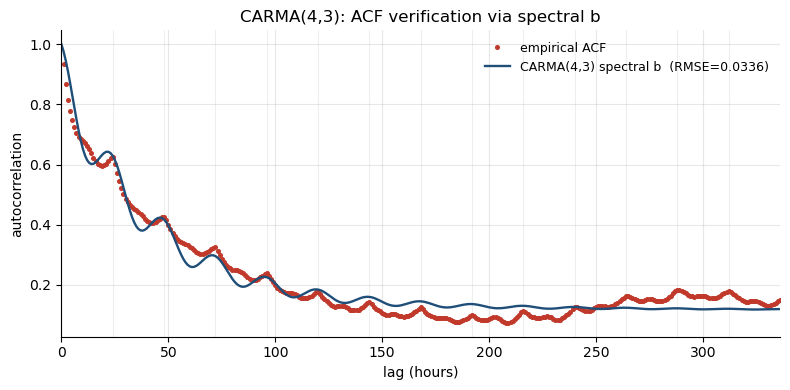

saved: price_multiscale_carma_selected.json
saved: price_carma_b_init.json

=== Init for nb03: p=4, q=3 ===
  b = [1.0000e+00, 9.7753e+02, 1.5524e+03, 1.4744e+04]


In [55]:
# ── Spectral factorisation CARMA(4,3) + sauvegarde ────────────────
from scipy.linalg import expm, solve_continuous_lyapunov

kap_r = kap_b[:Kr]; sh_r = sh_b[:Kr]
kap_c = kap_b[Kr:]; sh_c = sh_b[Kr:]
om_c  = np.array([2*np.pi/24.0])
p     = Kr + 2*Kc  # = 4

roots_ar = ([complex(-kap_r[i], 0) for i in range(Kr)] +
            [complex(-kap_c[0],  om_c[0]),
             complex(-kap_c[0], -om_c[0])])
ar = np.real(np.poly(roots_ar)[1:])

A = np.zeros((p, p))
for i in range(p-1): A[i, i+1] = 1.0
A[-1, :] = -ar[::-1]
ep = np.zeros(p); ep[-1] = 1.0
P_norm = solve_continuous_lyapunov(A, -np.outer(ep, ep))

fp_r2 = lambda k:    np.array([1., k**2])
fp_c2 = lambda k, o: np.array([1., 2*(k**2-o**2), (k**2+o**2)**2])
fr2 = [fp_r2(k) for k in kap_r]
fc2 = [fp_c2(k, o) for k, o in zip(kap_c, om_c)]

P_u = np.zeros(p)
for i in range(Kr):
    t = np.array([2*kap_r[i]*sh_r[i]*v0])
    for i2 in range(Kr):
        if i2 != i: t = np.polymul(t, fr2[i2])
    for j in range(Kc): t = np.polymul(t, fc2[j])
    P_u = np.polyadd(P_u, t)
for j in range(Kc):
    t = np.polymul(np.array([2*kap_c[j]*sh_c[j]*v0]),
                   np.array([1., kap_c[j]**2 + om_c[j]**2]))
    for i in range(Kr): t = np.polymul(t, fr2[i])
    P_u = np.polyadd(P_u, t)

print(f'P(u) degree={len(P_u)-1}  leading={P_u[0]:.4e}  '
      f'(expected 2v0·Σκw={2*v0*float(np.r_[kap_r,kap_c]@sh_b):.4e})')

u_roots = np.roots(P_u)
b_roots = np.array([1j*np.sqrt(uk) if np.real(1j*np.sqrt(uk)) < np.real(-1j*np.sqrt(uk))
                    else -1j*np.sqrt(uk) for uk in u_roots])
print(f'All b roots Re<0: {np.all(np.real(b_roots)<0)}  |  max Re={np.max(np.real(b_roots)):.2e}')

b_vec = np.real(np.poly(b_roots)[::-1])
b_vec = b_vec / b_vec[0]
Pb    = P_norm @ b_vec
var0  = float(b_vec @ Pb)
print(f'b = {np.array2string(b_vec, precision=4, separator=", ")}')
print(f'b^T·P_norm·b = {var0:.4e}  (v0={v0:.4e})')

# ── Vérification ACF ──────────────────────────────────────────────
eAh  = np.stack([expm(A*float(h)) for h in lags])
rho_sf = (eAh @ Pb) @ b_vec / var0
rmse_sf = float(np.sqrt(np.mean((rho_sf - rho_emp)**2)))
wssr_sf = float(np.sum((sw*(rho_sf - rho_emp))**2))
print(f'\n=== ACF verification ===')
print(f'  Multiscale model  RMSE={rmse_24:.6f}  WSSR={wssr_24:.4f}')
print(f'  Spectral b        RMSE={rmse_sf:.6f}  WSSR={wssr_sf:.4f}')
print(f'  ΔRMSE = {rmse_sf - rmse_24:.2e}  (should be ≈0)')

diag = [1,6,12,18,24,30,48,72,96,120,144,168,336,720,1440,2160]
eAhd = np.stack([expm(A*float(h)) for h in diag])
cmp  = pd.DataFrame({'lag_h': diag,
    'empirical'       : [acf(k) for k in diag],
    'multiscale'      : rho_24(best.x, np.array(diag, float)),
    'CARMA(4,3) sf-b' : (eAhd @ Pb) @ b_vec / var0})
cmp['err_sf'] = cmp['CARMA(4,3) sf-b'] - cmp['empirical']
display(cmp.style.format({c:'{:.4f}' for c in cmp.columns[1:]}).hide(axis='index'))

kk   = np.arange(0, 721)
eAhp = np.stack([expm(A*float(h)) for h in kk])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1,337), [acf(k) for k in range(1,337)],
        'o', ms=2.6, color='#c0392b', label='empirical ACF')
ax.plot(kk, (eAhp@Pb)@b_vec/var0, '-', lw=1.7, color='#1f4e79',
        label=f'CARMA(4,3) spectral b  (RMSE={rmse_sf:.4f})')
for d in range(24, 337, 24): ax.axvline(d, color='#eee', lw=0.8, zorder=0)
ax.set_xlim(0, 336); ax.set_xlabel('lag (hours)'); ax.set_ylabel('autocorrelation')
ax.set_title('CARMA(4,3): ACF verification via spectral b')
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()

# ── Sauvegarde ────────────────────────────────────────────────────
def _ser(x): return None if (isinstance(x, float) and not np.isfinite(x)) else float(x)

payload = dict(
    selected      = dict(Kr=Kr, Kc=Kc, order=p),
    roots         = [[float(r.real), float(r.imag)] for r in roots_ar],
    ar_coefficients = [float(x) for x in ar],
    b_coefficients  = b_vec.tolist(),
    metrics = dict(rmse_multiscale=float(rmse_24), wssr_multiscale=float(wssr_24),
                   rmse_spectral=float(rmse_sf),   wssr_spectral=float(wssr_sf)),
    components = [dict(kind=r['kind'], half_life_d=float(r['half_life_d']),
                       period_h=_ser(r['period_h']), share=float(r['share']))
                  for _, r in summary_24.iterrows()],
    note = 'Kr=2 Kc=1 period=24h fixed t_half_osc>=2d. CARMA(4,3). No sigma: model is dX=AX dt+ep dL(t).'
)
(OUT/'price_multiscale_carma_selected.json').write_text(json.dumps(payload, indent=2))
(OUT/'price_carma_b_init.json').write_text(json.dumps(dict(
    b_coefficients=b_vec.tolist(),
    AR_order=int(p), MA_order=int(p-1),
    acf_rmse_spectral=float(rmse_sf), acf_rmse_multiscale=float(rmse_24),
    note=f'CARMA({p},{p-1}) spectral b. Kr=2 Kc=1 period=24h fixed. No sigma.'), indent=2))
print('saved: price_multiscale_carma_selected.json')
print('saved: price_carma_b_init.json')
print(f'\n=== Init for nb03: p={p}, q={p-1} ===')
print(f'  b = {np.array2string(b_vec, precision=4, separator=", ")}')
